# 📈 Analyse Exploratoire des Séries Temporelles (EDA)

L'objectif de cette première étape est de comprendre le comportement de nos ventes historiques sur 3 ans (2020-2022). 
Dans une série temporelle, on cherche généralement à identifier 3 composantes principales :
1. **La Tendance (Trend)** : L'évolution globale à long terme (les ventes augmentent-elles d'année en année ?)
2. **La Saisonnalité (Seasonality)** : Les motifs qui se répètent à intervalles réguliers (les week-ends, l'été, Noël...)
3. **Le Bruit (Residuals/Noise)** : Les variations aléatoires imprévisibles.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

# Configuration visuelle
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## 1. Chargement et Formatage des Données

In [2]:
# Chargement du fichier CSV
df = pd.read_csv('../data/store_sales.csv')

# ⚠️ Étape CRUCIALE en séries temporelles :
# Il faut convertir la colonne 'Date' au format datetime de pandas et la définir comme index (index temporel)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

display(df.head())
print(f"Le dataset s'étend du {df.index.min().date()} au {df.index.max().date()}")

,Sales
Date,
2020-01-01,497
2020-01-02,481
2020-01-03,508
2020-01-04,607
2020-01-05,557


Le dataset s'étend du 2020-01-01 au 2022-12-31


## 2. Visualisation Globale des Ventes

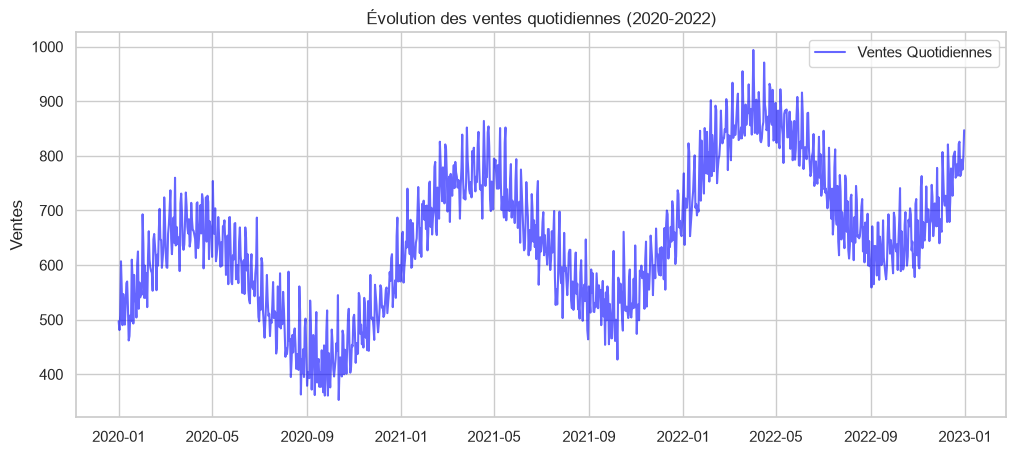

In [3]:
plt.plot(df.index, df['Sales'], color='blue', alpha=0.6, label='Ventes Quotidiennes')
plt.title('Évolution des ventes quotidiennes (2020-2022)')
plt.ylabel('Ventes')
plt.legend()
plt.show()

Ce graphique quotidien est très "bruité" (il monte et descend sans cesse). 
Pour y voir plus clair, faisons des **moyennes glissantes (Rolling Mean)** ou regroupons les données par mois.

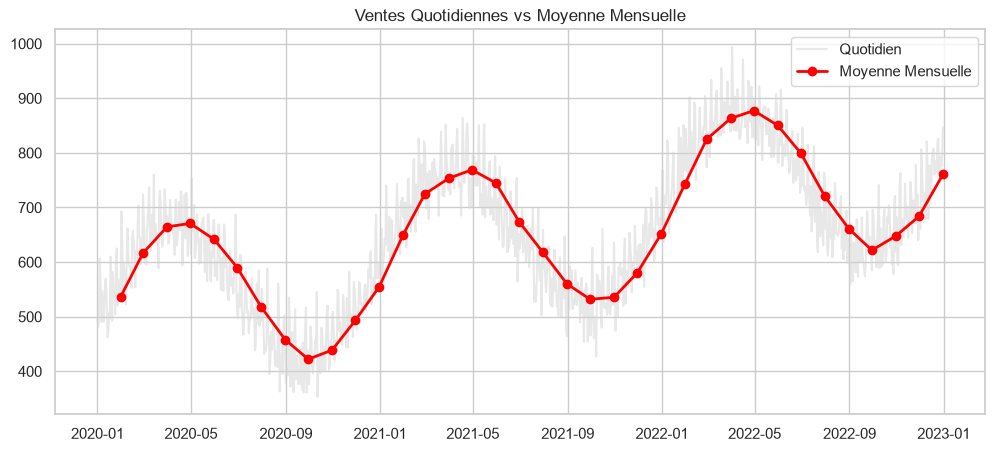

In [4]:
# Regroupement par mois (Resampling)
df_monthly = df.resample('ME').mean() # Moyenne des ventes pour chaque mois (ME = Month End)

plt.plot(df.index, df['Sales'], color='lightgrey', alpha=0.5, label='Quotidien')
plt.plot(df_monthly.index, df_monthly['Sales'], color='red', marker='o', linewidth=2, label='Moyenne Mensuelle')
plt.title('Ventes Quotidiennes vs Moyenne Mensuelle')
plt.legend()
plt.show()

Ici, on voit beaucoup mieux **la tendance à la hausse** et les **pics saisonniers** récurrents chaque année !

## 3. Décomposition de la Série Temporelle

Utilisons `statsmodels` pour séparer mathématiquement notre série en ses 3 composantes fondamentales.

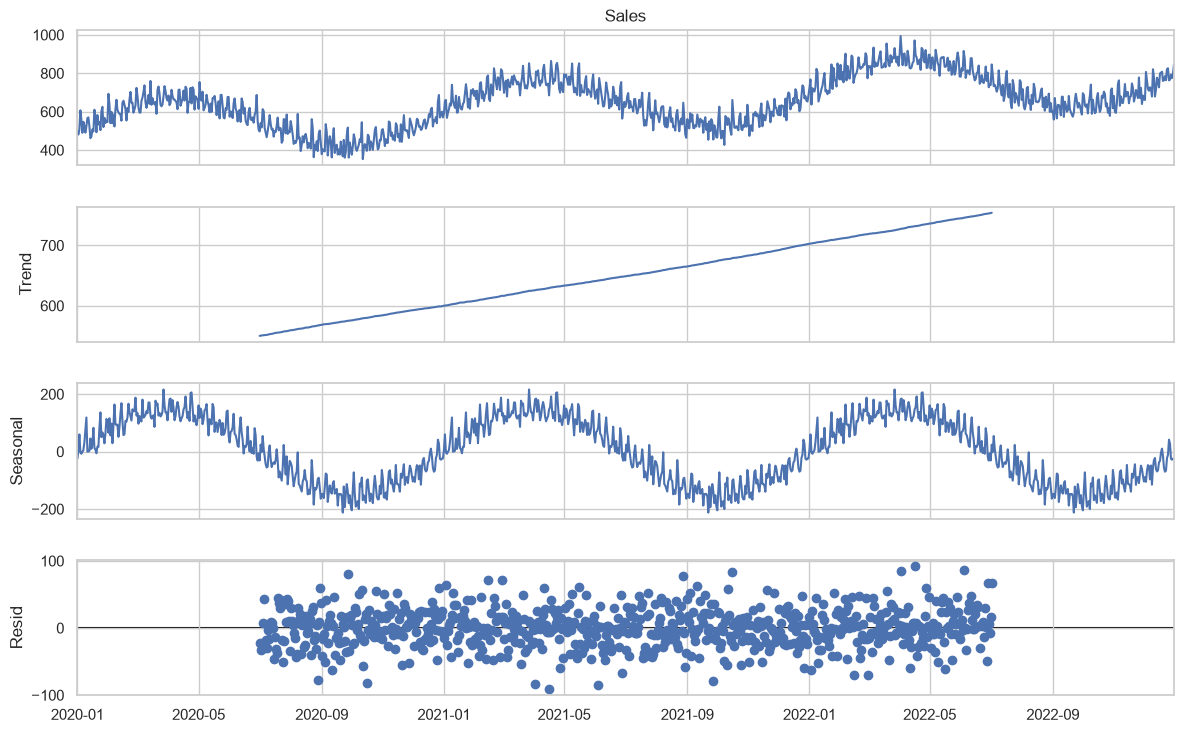

In [5]:
# On effectue une décomposition sur une période de 365 jours (car nos données sont quotidiennes)
decomposition = seasonal_decompose(df['Sales'], model='additive', period=365)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

**Interprétation des 4 graphiques :**
- **Observed** : La vraie courbe des ventes.
- **Trend** : La tendance pure. On voit clairement une belle croissance linéaire !
- **Seasonal** : Le motif annuel qui se répète à l'identique (pics en été et creux en hiver dans notre cas).
- **Resid** : Le bruit restant qu'on ne peut pas expliquer avec le Trend et la Saisonnalité.